### Code for sanity checking data from sub1

In [3]:
#Load packagaes
import mne
import matplotlib_inline
import matplotlib.pyplot as plt
import os
import numpy as np
import os.path as op
import warnings
import inspect
from mne_bids import (
    BIDSPath,
    make_dataset_description,
    print_dir_tree,
    read_raw_bids,
)

warnings.filterwarnings('ignore')

file path structure: <BIDS_ROOT>/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_meg.fif

/Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_meg.fif

In [22]:
subject = '02'  
session = '01'  
task = 'face'
run = '01'  
meg_suffix = 'meg'
meg_extension = '.fif'
events_suffix = 'events'
events_extension = '.tsv'

# data_path='/Users/rekaforgo/Documents/Bachelor2025'
data_path = '/Users/rekaforgo/Documents/Bachelor2025'


bids_path = BIDSPath(subject=subject, session=session,
                     task=task, run=run, suffix=meg_suffix, 
                     extension=meg_extension, root=data_path)



In [23]:
print(bids_path)


# Read the raw data
raw = read_raw_bids(bids_path=bids_path, 
                    verbose=False,
                    extra_params={'preload': True})

/Users/rekaforgo/Documents/Bachelor2025/sub-02/ses-01/sub-02_ses-01_task-face_run-01_meg.fif


In [24]:
print(raw)

<Raw | SHA256E-s85488268--a81b5d65d14a87f958ad322801cb28804c73375dd7357c52f174241332611b3d.fif, 65 x 328750 (328.8 s), ~163.1 MiB, data loaded>


In [25]:
print(raw.info)

<Info | 12 non-empty values
 bads: []
 ch_names: MEG01, MEG02, MEG03, MEG04, MEG05, MEG06, MEG07, MEG08, MEG09, ...
 chs: 64 Magnetometers, 1 Stimulus
 custom_ref_applied: False
 experimenter: PKU XU WEI
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 500.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 65
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: sub-02, sex: 1, hand: 1>
>


In [26]:
ch_names = raw.info['ch_names']
print(ch_names)

['MEG01', 'MEG02', 'MEG03', 'MEG04', 'MEG05', 'MEG06', 'MEG07', 'MEG08', 'MEG09', 'MEG10', 'MEG11', 'MEG12', 'MEG13', 'MEG14', 'MEG15', 'MEG16', 'MEG17', 'MEG18', 'MEG19', 'MEG20', 'MEG21', 'MEG22', 'MEG23', 'MEG24', 'MEG25', 'MEG26', 'MEG27', 'MEG28', 'MEG29', 'MEG30', 'MEG31', 'MEG32', 'MEG33', 'MEG34', 'MEG35', 'MEG36', 'MEG37', 'MEG38', 'MEG39', 'MEG40', 'MEG41', 'MEG42', 'MEG43', 'MEG44', 'MEG45', 'MEG46', 'MEG47', 'MEG48', 'MEG49', 'MEG50', 'MEG51', 'MEG52', 'MEG53', 'MEG54', 'MEG55', 'MEG56', 'MEG57', 'MEG58', 'MEG59', 'MEG60', 'MEG61', 'MEG62', 'MEG63', 'MEG64', 'STIM']


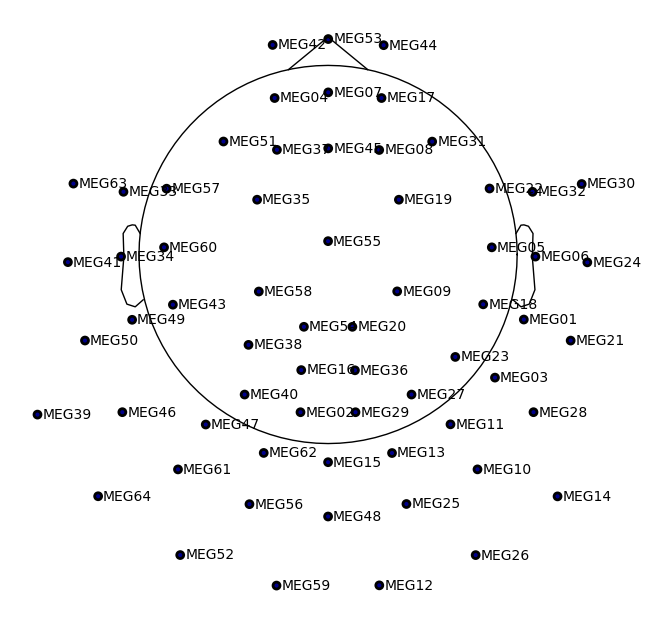

In [27]:
raw.plot_sensors(kind='topomap', show_names=True);

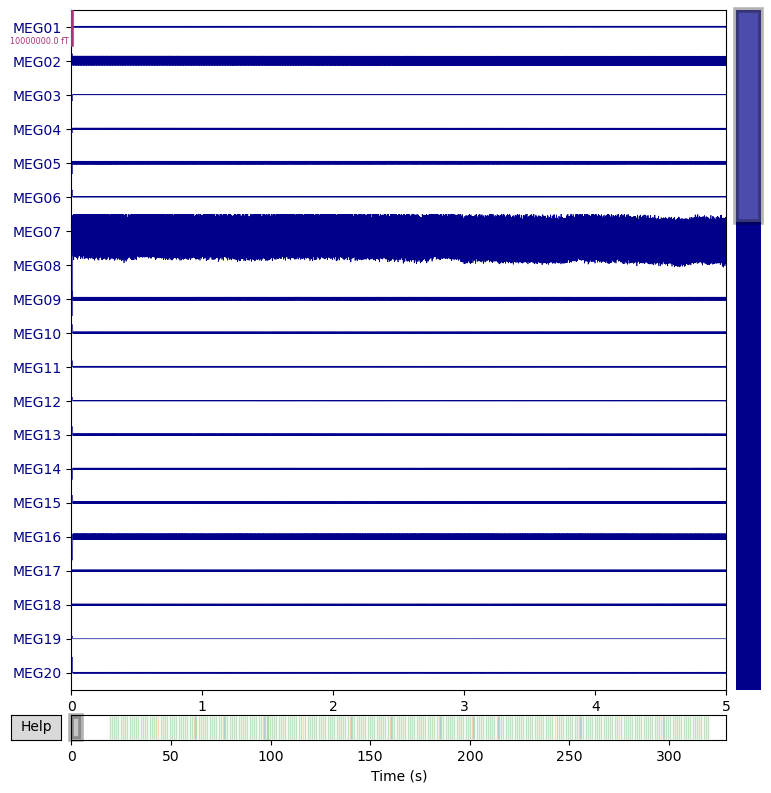

In [28]:
raw.plot(
    picks='mag',
    duration=5,
    proj=False,
    scalings=5e-9   # 5 nT
);

In [ ]:
#for ch in mne.pick_types(raw.info, meg=True, stim=False):
 #   raw.info['chs'][ch]['unit'] = mne.io.constants.FIFF.FIFF_UNIT_T
  #  raw.info['chs'][ch]['unit_mul'] = 0


Note that in the FLUX pipeline they calculate the power spectra for only one dimension of sensors. Their sensors are named OPM *X* OPM *Y* and OPM *Z* based on the dimension. They say it is easier to compute PSD for the Z dimension. Plus they also mark the bad channels.

In [29]:


n_fft = 2000 # achieving a 0.5 Hz frequency resolution
raw_psd = raw.compute_psd('welch', fmin=0.0, fmax=120, picks="mag", n_fft=n_fft, n_overlap=int(n_fft // 2))

Effective window size : 2.000 (s)


Note the 50 Hz line noise. The frequency of the line noise is 50 Hz in European countries including Russia as well as Asian countries including India and China. It is 60 in South Korea as well as South and North America. In Japan it will be either 50 or 60 Hz depending on the region.

Plotting power spectral density (dB=True).


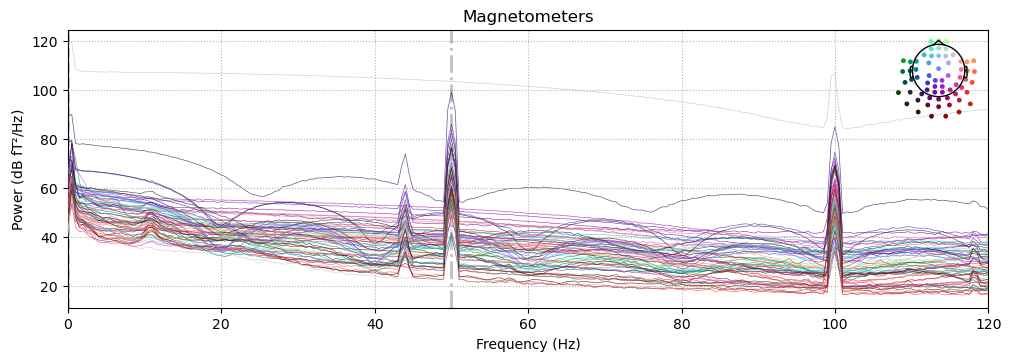

In [30]:
raw_psd.plot();

## Applying MAX filter and identifying noise

In [19]:
import os.path as op
import os
import sys
import numpy as np

import mne
from mne_bids import BIDSPath, read_raw_bids
import matplotlib.pyplot as plt
import scipy

[<DigPoint |        LPA : (-82.5, 0.0, 0.0) mm      : head frame>, <DigPoint |     Nasion : (-0.0, 114.0, 0.0) mm     : head frame>, <DigPoint |        RPA : (82.5, -0.0, -0.0) mm     : head frame>]
Applying notch filters...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 43 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 43.39
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 43.14 Hz)
- Upper passband edge: 44.61 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 44.86 Hz)
- Filter length: 6601 samples (6.601 s)

Setting up band-stop filter from 43 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming wind

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Applying notch filters at: [ 50 100 150 200 250] Hz
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 6601 samples (6.601 s)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Applying bandpass filter (1-100 Hz)...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 3301 samples (3.301 s)

Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s


Filtering complete!


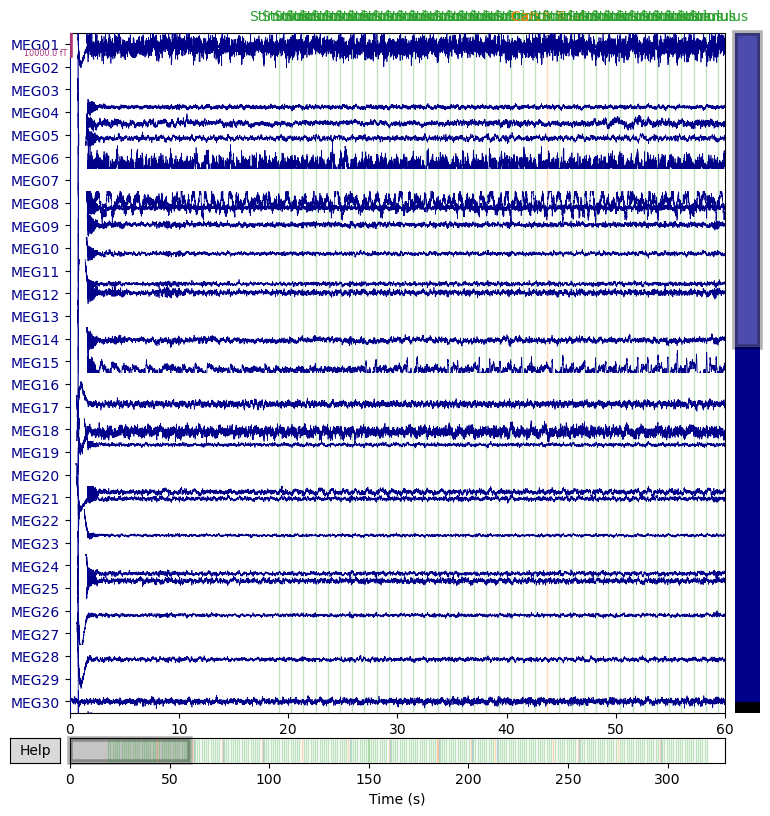

In [45]:
raw.info['bads'] = []

print(raw.info['dig'])

# Following the filtering pipeline from the paper:
# 1. Notch filter at 44 Hz (electronic system noise)
# 2. Notch filters at 50, 100, 150, 200, 250 Hz (line noise and harmonics)
# 3. Bandpass filter 1-100 Hz

print("Applying notch filters...")

# Make a copy of raw data for filtering
filtered = raw.copy()

# Apply notch filter at 44 Hz for electronic system noise
filtered.notch_filter(freqs=44, filter_length='auto', phase='zero', 
                     fir_design='firwin', verbose=True)

# Apply notch filters for line noise (50 Hz) and its harmonics up to 250 Hz
line_freqs = np.arange(50, 251, 50)  # [50, 100, 150, 200, 250] Hz
print(f"Applying notch filters at: {line_freqs} Hz")

filtered.notch_filter(freqs=line_freqs, filter_length='auto', phase='zero',
                     fir_design='firwin', verbose=True)

# Apply bandpass filter between 1-100 Hz using FIR filter
# Phase='zero' ensures zero-phase filtering (shifts backward to compensate for phase delay)
print("Applying bandpass filter (1-100 Hz)...")
filtered.filter(l_freq=1.0, h_freq=100.0, method='fir', phase='zero',
               fir_design='firwin', verbose=True)

print("Filtering complete!")

# Plot the filtered data
filtered.plot(duration=60, n_channels=30, scalings={'mag': 5e-12});

Computing PSD for comparison...
Effective window size : 2.000 (s)
Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


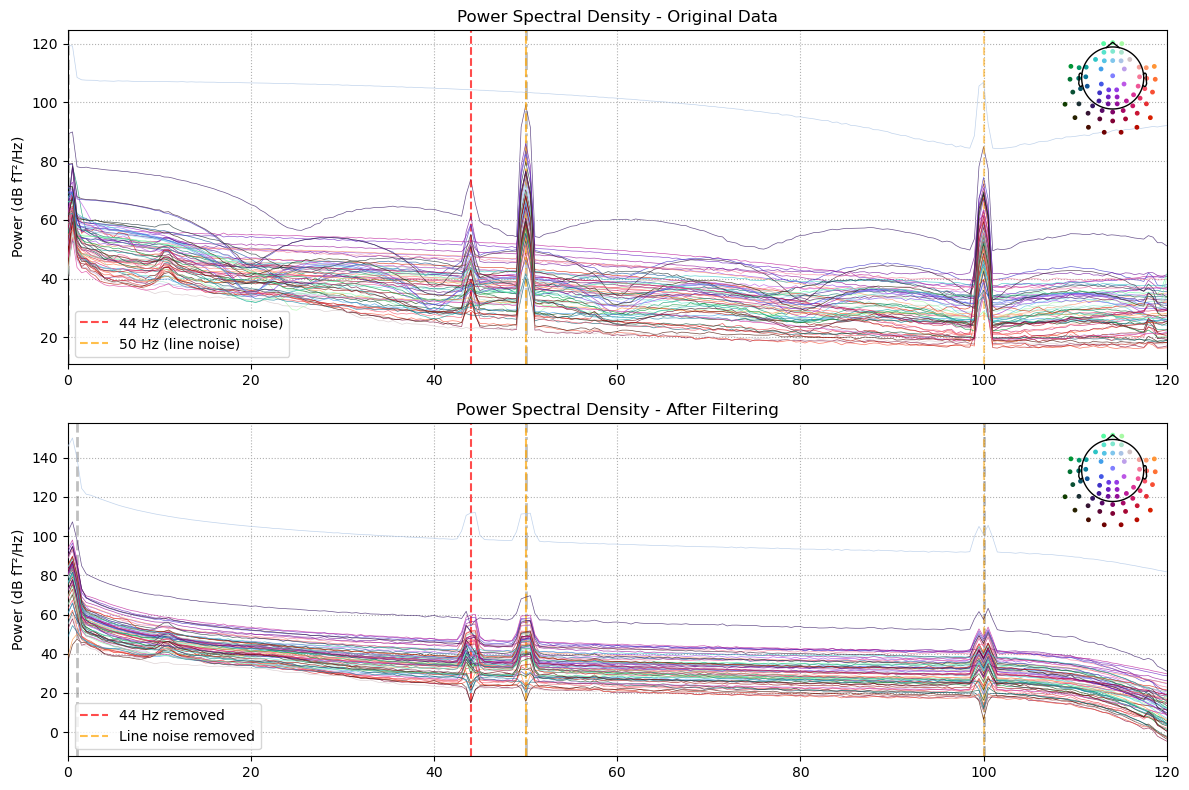

In [48]:
# Compare power spectral density before and after filtering
print("Computing PSD for comparison...")

# PSD of original data
n_fft = 2000  # 0.5 Hz frequency resolution
raw_psd = raw.compute_psd('welch', fmin=0.0, fmax=120, picks="mag", 
                         n_fft=n_fft, n_overlap=int(n_fft // 2))

# PSD of filtered data
filtered_psd = filtered.compute_psd('welch', fmin=0.0, fmax=120, picks="mag",
                                   n_fft=n_fft, n_overlap=int(n_fft // 2))

# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Original data PSD
raw_psd.plot(axes=ax1, show=False, average=False, amplitude=False)
ax1.set_title('Power Spectral Density - Original Data')
ax1.axvline(x=44, color='red', linestyle='--', alpha=0.7, label='44 Hz (electronic noise)')
ax1.axvline(x=50, color='orange', linestyle='--', alpha=0.7, label='50 Hz (line noise)')
ax1.axvline(x=100, color='orange', linestyle='--', alpha=0.5)
ax1.legend()

# Filtered data PSD
filtered_psd.plot(axes=ax2, show=False, average=False, amplitude=False)
ax2.set_title('Power Spectral Density - After Filtering')
ax2.axvline(x=44, color='red', linestyle='--', alpha=0.7, label='44 Hz removed')
ax2.axvline(x=50, color='orange', linestyle='--', alpha=0.7, label='Line noise removed')
ax2.axvline(x=100, color='orange', linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

## Filtering Pipeline Implementation

This filtering pipeline follows the methodology described in recent OPM-MEG literature:

1. **Notch filter at 44 Hz**: Removes electronic system noise
2. **Notch filters at 50, 100, 150, 200, 250 Hz**: Removes line noise (50 Hz) and its harmonics
3. **Bandpass filter 1-100 Hz**: 
   - High-pass at 1 Hz removes slow drift in raw data
   - Low-pass at 100 Hz removes high-frequency noise
   - Uses zero-phase FIR filter to avoid phase distortion

Key parameters:
- `phase='zero'`: Ensures zero-phase filtering by shifting backward to compensate for phase delay
- `method='fir'`: Uses finite impulse response filter as specified in the paper
- `fir_design='firwin'`: Uses windowed FIR filter design

This approach is consistent with Hill et al. (2020), Westner et al. (2021), Iivanainen et al. (2023), and Rier et al. (2023).

In [49]:
#marking bad channels

print(raw.info)

<Info | 13 non-empty values
 bads: []
 ch_names: MEG01, MEG02, MEG03, MEG04, MEG05, MEG06, MEG07, MEG08, MEG09, ...
 chs: 64 Magnetometers, 1 Stimulus
 custom_ref_applied: False
 dig: 3 items (3 Cardinal)
 experimenter: PKU XU WEI
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 500.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 65
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: sub-02, sex: 1, hand: 1>
>


In [ ]:
#Doing ICA

for subfile in range(2):
    raw = read_raw_bids(bids_path=bids_path, 
                     extra_params={'preload':True},
                     verbose=True)
    raw_resmpl = raw.copy().pick('meg')
    raw_resmpl.resample(200) # dowsample to 200 Hz
    raw_resmpl.filter(1, 40) # band-pass filtert from 1 to 40 Hz
    if subfile == 0:
        raw_resmpl_all = mne.io.concatenate_raws([raw_resmpl])
        bids_path.update(run='02')
    else:
        raw_resmpl_all = mne.io.concatenate_raws([raw_resmpl_all, raw_resmpl])
del raw_resmpl